In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

physician_fee_schedules = {}

base_path = "../../Data/Reimbursement_CPT_Codes"

columns_to_keep = ["HCPCS Code", "Facility Price"]

for year in range(2000, 2026):
    file_path = f"{base_path}/{year}.csv"
    df = pd.read_csv(file_path)
    df = df.loc[:, df.columns.intersection(columns_to_keep)].copy()
    df["Year"] = year
    physician_fee_schedules[year] = df

combined_df = pd.concat(physician_fee_schedules.values(), ignore_index=True)

combined_df = combined_df[["Year", "HCPCS Code", "Facility Price"]]

inflation_path = "../../Data/Inflation_Table/inflation_table.csv"
inflation_df = pd.read_csv(inflation_path)

combined_df = combined_df.merge(inflation_df, on="Year", how="left")

combined_df["Facility Price"] = pd.to_numeric(combined_df["Facility Price"], errors="coerce")

combined_df["Facility Price (Inflation Adjusted)"] = (
    combined_df["Facility Price"] * combined_df["Inflation Factor"]
)

In [2]:
grouping_path = "../../Supplementary_Tables/ST1/ST1.csv"
grouping_df = pd.read_csv(grouping_path)

combined_df["HCPCS Code"] = combined_df["HCPCS Code"].astype(str)
grouping_df["CPT Code"] = grouping_df["CPT Code"].astype(str)

combined_df = combined_df.merge(
    grouping_df[["CPT Code", "Group Name", "Group Number"]],
    left_on="HCPCS Code",
    right_on="CPT Code",
    how="left"
)

combined_df = combined_df.drop(columns=["CPT Code"])

grouped_df = (
    combined_df
    .groupby(["Year", "Group Name"], as_index=False)
    .mean(numeric_only=True)
)

facility_price = grouped_df.pivot(
    index="Group Name",
    columns="Year",
    values="Facility Price"
).sort_index(axis=1)

inflation_facility_price = grouped_df.pivot(
    index="Group Name",
    columns="Year",
    values="Facility Price (Inflation Adjusted)"
).sort_index(axis=1)


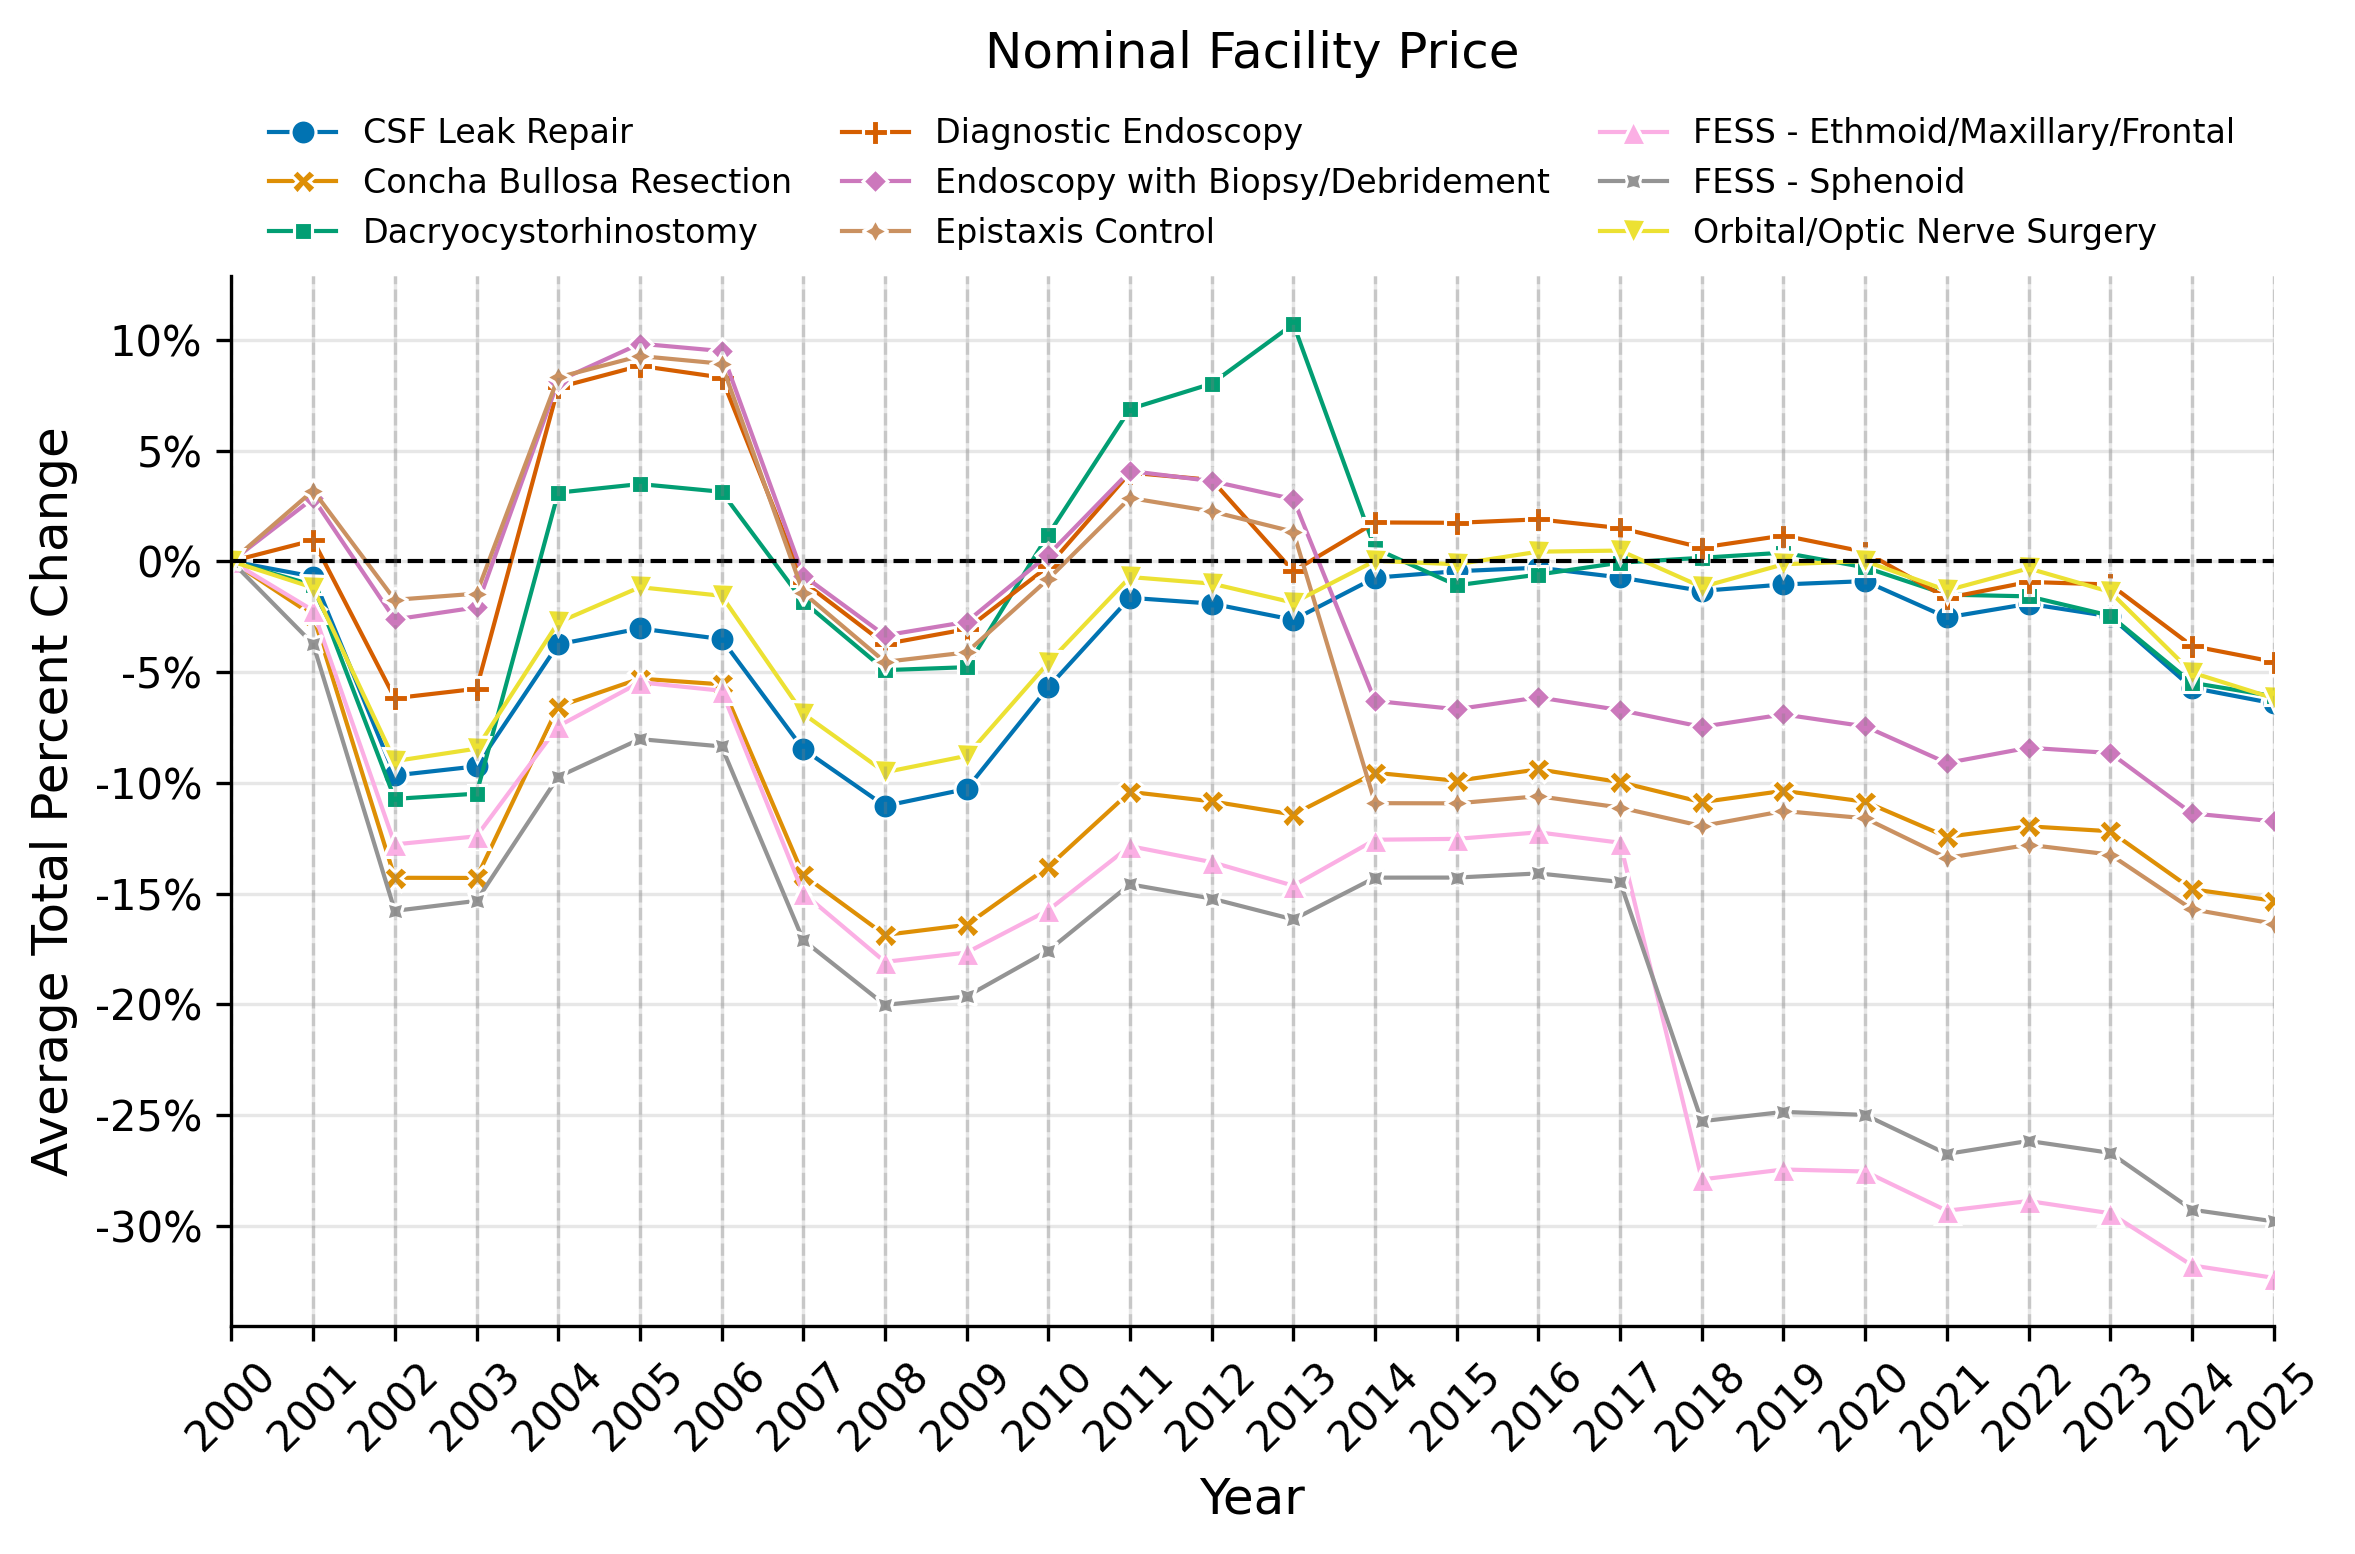

In [3]:
baseline_year = 2000

facility_pct_change = (
    facility_price
    .subtract(facility_price[baseline_year], axis=0)
    .divide(facility_price[baseline_year], axis=0)
    * 100
)

plot_df = (
    facility_pct_change
    .reset_index()
    .melt(
        id_vars="Group Name",
        var_name="Year",
        value_name="Percent Change"
    )
)

plot_df["Year"] = plot_df["Year"].astype(int)

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

sns.lineplot(
    data=plot_df,
    x="Year",
    y="Percent Change",
    hue="Group Name",
    markers=True,
    palette="colorblind",
    style="Group Name",
    dashes=False,
    markersize=6,
    linewidth=1,
    ax=ax
)

plt.axhline(0, linestyle="--", color="black", linewidth=1)

plt.title("Nominal Facility Price", fontsize=12, pad=50)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Total Percent Change", fontsize=12)

ax.set_xlim(2000, 2025)
ax.set_xticks(range(2000, 2026))
plt.xticks(rotation=45)

ax.yaxis.set_major_locator(mtick.MultipleLocator(5))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%g%%'))

ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=3,                
    frameon=False,
    fontsize=8,
    handlelength=2.0,
    columnspacing=1.5
)

plt.grid(alpha=0.3)
for year in range(2000, 2026):
    plt.axvline(x=year, linestyle="--", color="gray", alpha=0.3, linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('F1A.pdf')
plt.show()

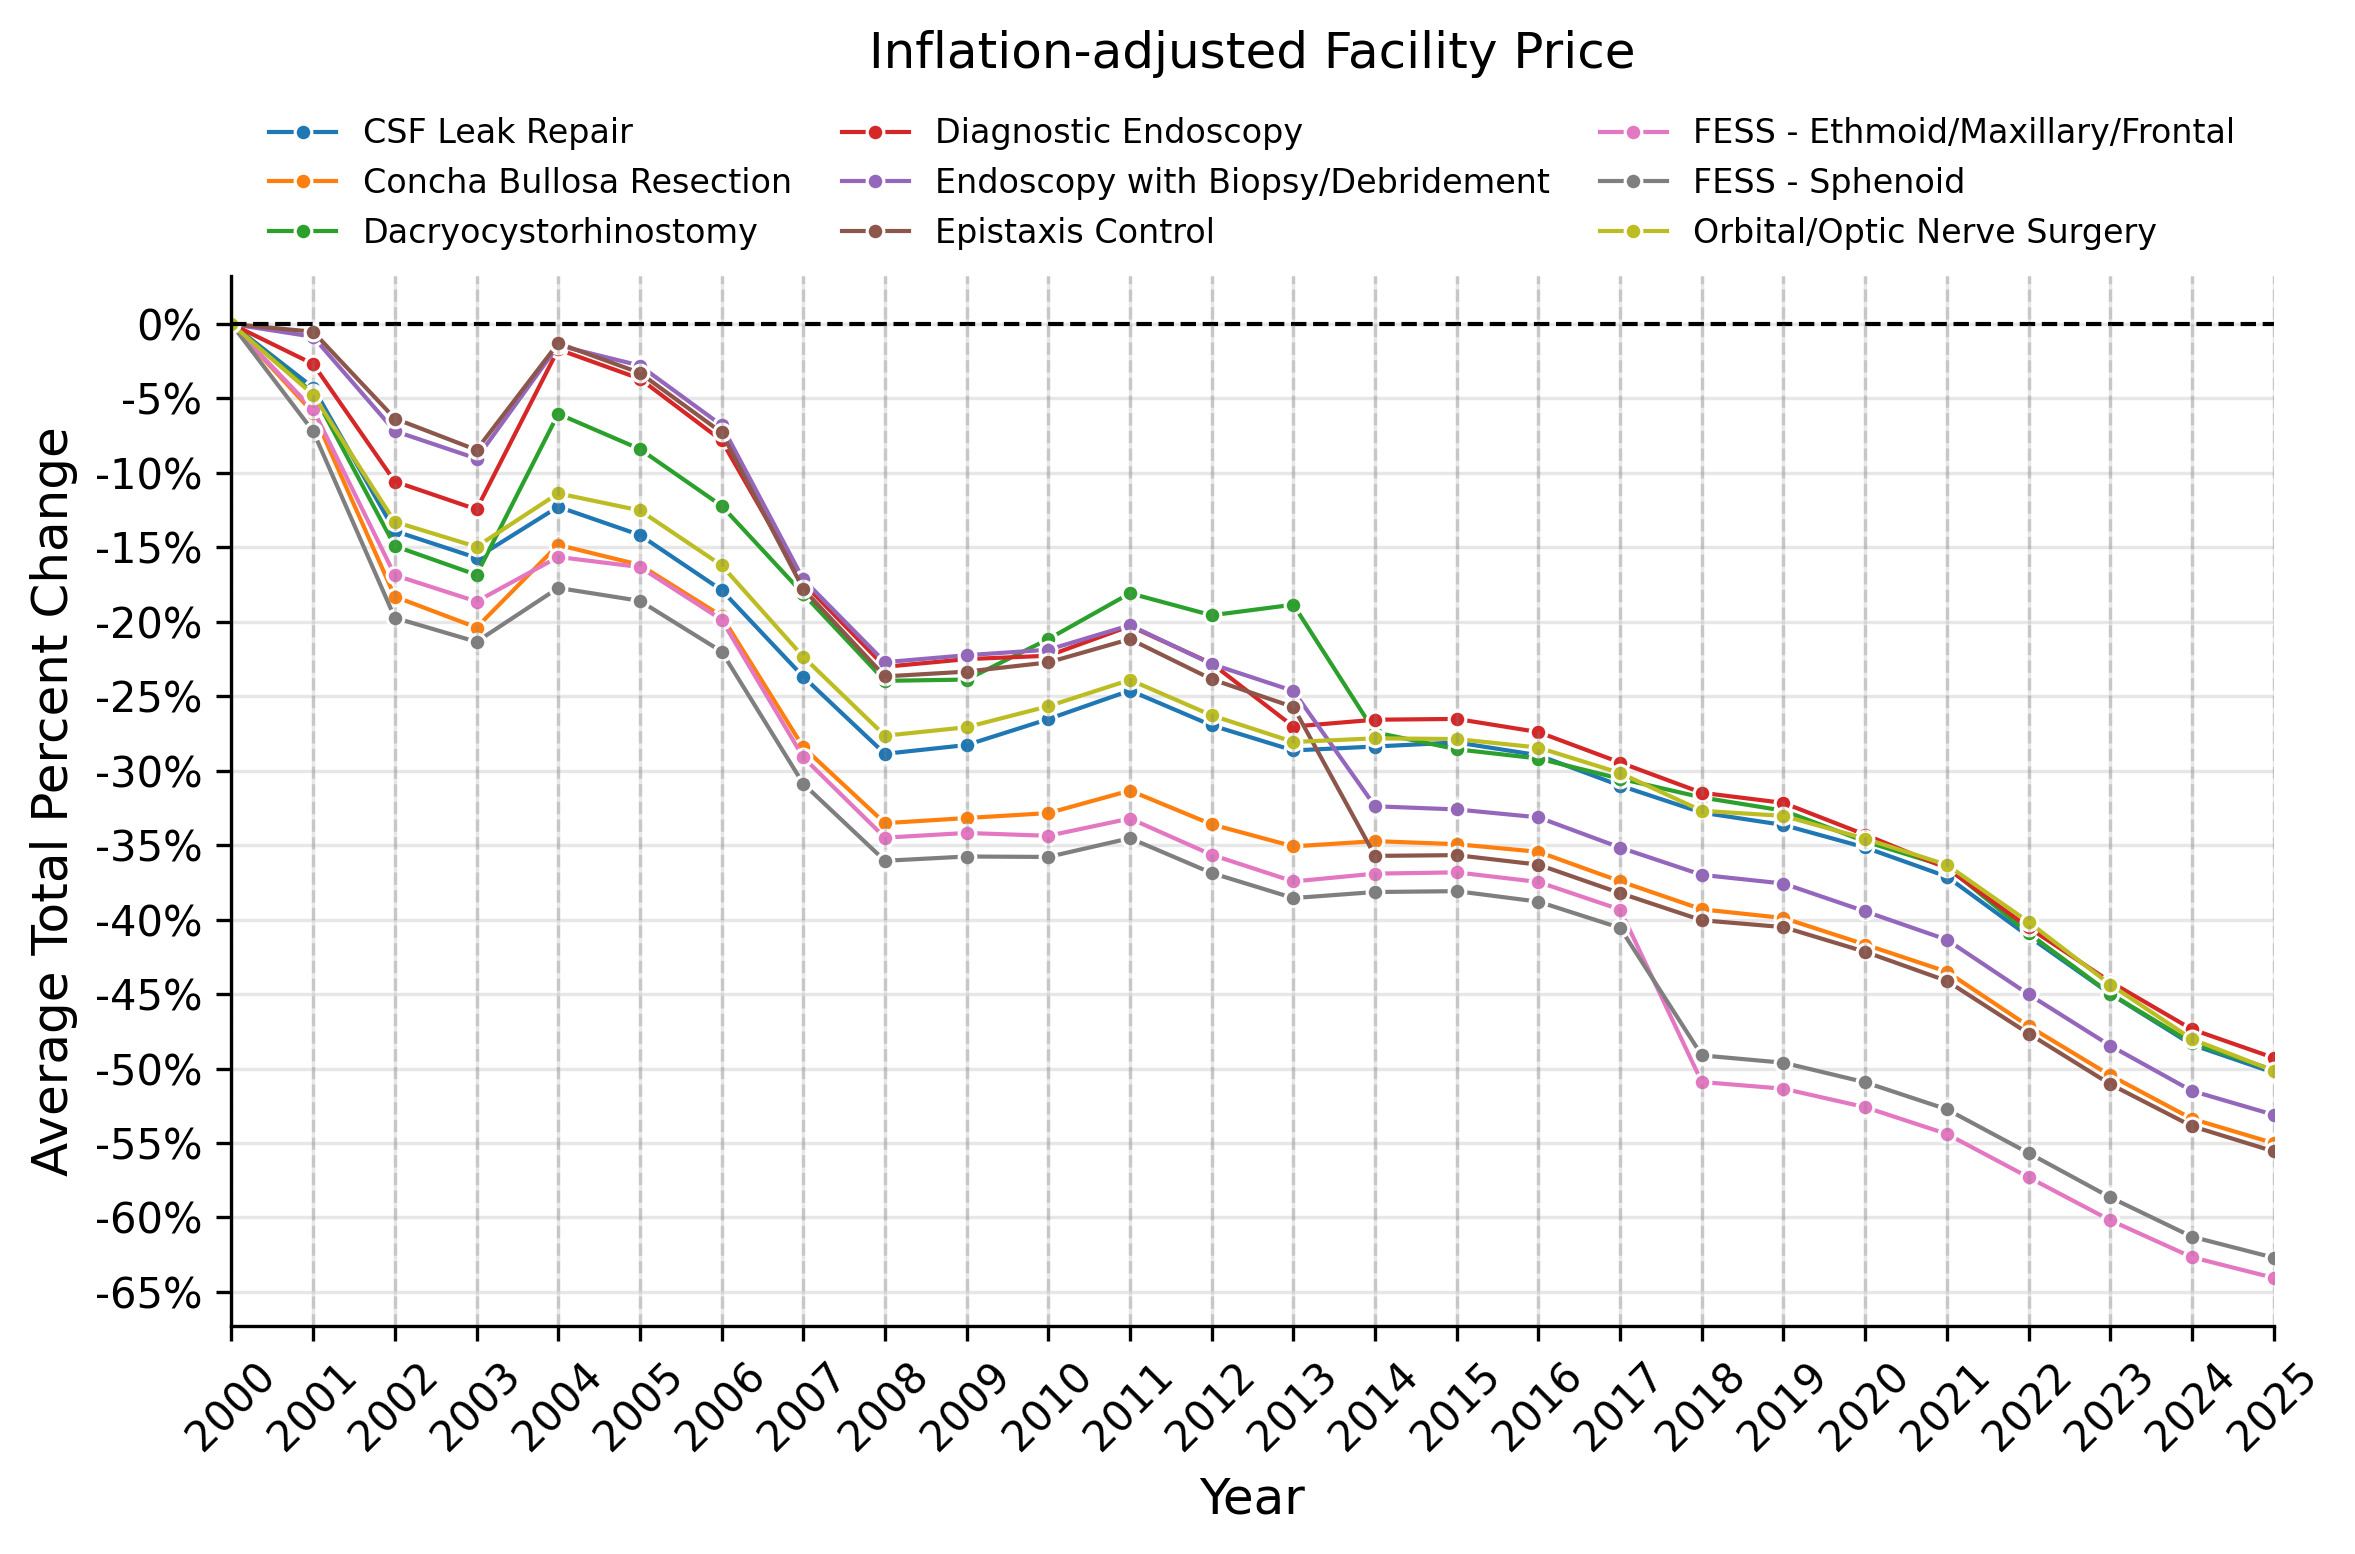

In [4]:
baseline_year = 2000

facility_pct_change = (
    inflation_facility_price
    .subtract(inflation_facility_price[baseline_year], axis=0)
    .divide(inflation_facility_price[baseline_year], axis=0)
    * 100
)

plot_df = (
    facility_pct_change
    .reset_index()
    .melt(
        id_vars="Group Name",
        var_name="Year",
        value_name="Percent Change"
    )
)

plot_df["Year"] = plot_df["Year"].astype(int)

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

sns.lineplot(
    data=plot_df,
    x="Year",
    y="Percent Change",
    hue="Group Name",
    marker="o",
    style="Group Name",
    dashes=False,
    markersize=4,
    linewidth=1,
    ax=ax
)

plt.axhline(0, linestyle="--", color="black", linewidth=1)

plt.title("Inflation-adjusted Facility Price", fontsize=12, pad=50)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Total Percent Change", fontsize=12)

ax.set_xlim(2000, 2025)
ax.set_xticks(range(2000, 2026))
plt.xticks(rotation=45)

ax.yaxis.set_major_locator(mtick.MultipleLocator(5))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%g%%'))

ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=3,                
    frameon=False,
    fontsize=8,
    handlelength=2.0,
    columnspacing=1.5
)

plt.grid(alpha=0.3)
for year in range(2000, 2026):
    plt.axvline(x=year, linestyle="--", color="gray", alpha=0.3, linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('F1B.pdf')
plt.show()